# 04. Visualización 2D del registro entre pares

Este notebook evita el uso de visualización interactiva con Open3D y emplea únicamente `matplotlib`, lo que lo hace más estable en WSL.

Contenido de la visualización:
- pseudo-LiDAR en `t` y `t+1` antes del registro,
- pseudo-LiDAR después de aplicar ICP,
- LiDAR GT para la misma pareja de frames,
- y comparación entre el movimiento real y el movimiento estimado.


In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from pyquaternion import Quaternion
from nuscenes.nuscenes import NuScenes


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
ROOT = Path('/home/clara/ml-depth-pro/slam_readiness_nuscenes')
RUN_SUMMARY = ROOT / 'outputs' / 'scene-0061' / 'run_summary.json'
PAIRWISE_METRICS = ROOT / 'outputs' / 'scene-0061' / 'pairwise_registration_metrics.json'
DATAROOT = Path('/home/clara/datasets/nuscenes')
VERSION = 'v1.0-mini'

PAIR_INDEX = 0
VOXEL_SIZE = 0.5
MAX_CORR_DIST = 1.5
PLOT_XLIM = (-35, 35)
PLOT_YLIM = (-35, 35)

run_summary = json.loads(RUN_SUMMARY.read_text())
pairwise_metrics = json.loads(PAIRWISE_METRICS.read_text()) if PAIRWISE_METRICS.exists() else None
nusc = NuScenes(version=VERSION, dataroot=str(DATAROOT), verbose=False)

samples = sorted(run_summary['samples'], key=lambda x: x['index'])
samples


[{'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
  'index': 0,
  'timestamp_s': 1532402927.647951,
  'ring_path': '/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/ca9a282c9e77460f8360f564131a8af5/pcd_ring_6cams_ego.ply',
  'pseudo_path': '/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/ca9a282c9e77460f8360f564131a8af5/pcd_pseudolidar_ego.ply',
  'lidar_path': '/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/ca9a282c9e77460f8360f564131a8af5/pcd_lidar_top_ego.ply',
  'ring_num_points': 281010,
  'pseudo_num_points': 23534},
 {'sample_token': '39586f9d59004284a7114a68825e8eec',
  'index': 1,
  'timestamp_s': 1532402928.147847,
  'ring_path': '/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/39586f9d59004284a7114a68825e8eec/pcd_ring_6cams_ego.ply',
  'pseudo_path': '/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/39586f9d59004284a7114a68825e8eec/pcd_pseudolidar_ego.ply',
  'lidar_path': 

In [3]:
def transform_from_translation_rotation(translation, rotation):
    transform = np.eye(4, dtype=np.float64)
    transform[:3, :3] = Quaternion(rotation).rotation_matrix
    transform[:3, 3] = np.asarray(translation, dtype=np.float64)
    return transform


def pose_global_from_sample(nusc, sample_token):
    sample = nusc.get('sample', sample_token)
    lidar_sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
    ego_pose = nusc.get('ego_pose', lidar_sd['ego_pose_token'])
    return transform_from_translation_rotation(ego_pose['translation'], ego_pose['rotation'])


def relative_transform(source_global, target_global):
    return np.linalg.inv(target_global) @ source_global


def load_points(path):
    pcd = o3d.io.read_point_cloud(str(path))
    return np.asarray(pcd.points, dtype=np.float64)


def load_and_prepare_pcd(path, voxel_size):
    pcd = o3d.io.read_point_cloud(str(path))
    pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=voxel_size * 4.0, max_nn=30)
    )
    return pcd


def register_pair(source, target, max_corr_dist):
    return o3d.pipelines.registration.registration_icp(
        source,
        target,
        max_corr_dist,
        np.eye(4),
        o3d.pipelines.registration.TransformationEstimationPointToPlane(),
        o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=100),
    )


def apply_transform(points, transform):
    points_h = np.concatenate([points, np.ones((points.shape[0], 1), dtype=np.float64)], axis=1)
    return (transform @ points_h.T).T[:, :3]


def rotation_angle_deg(transform):
    r = transform[:3, :3]
    trace = np.clip((np.trace(r) - 1.0) * 0.5, -1.0, 1.0)
    return math.degrees(math.acos(trace))


In [4]:
src_meta = samples[PAIR_INDEX]
tgt_meta = samples[PAIR_INDEX + 1]

src_pseudo_points = load_points(Path(src_meta['pseudo_path']))
tgt_pseudo_points = load_points(Path(tgt_meta['pseudo_path']))
src_gt_points = load_points(Path(src_meta['lidar_path']))
tgt_gt_points = load_points(Path(tgt_meta['lidar_path']))

src_pseudo_pcd = load_and_prepare_pcd(Path(src_meta['pseudo_path']), VOXEL_SIZE)
tgt_pseudo_pcd = load_and_prepare_pcd(Path(tgt_meta['pseudo_path']), VOXEL_SIZE)
src_gt_pcd = load_and_prepare_pcd(Path(src_meta['lidar_path']), VOXEL_SIZE)
tgt_gt_pcd = load_and_prepare_pcd(Path(tgt_meta['lidar_path']), VOXEL_SIZE)

pseudo_icp = register_pair(src_pseudo_pcd, tgt_pseudo_pcd, MAX_CORR_DIST)
gt_icp = register_pair(src_gt_pcd, tgt_gt_pcd, MAX_CORR_DIST)

src_pose = pose_global_from_sample(nusc, src_meta['sample_token'])
tgt_pose = pose_global_from_sample(nusc, tgt_meta['sample_token'])
gt_rel = relative_transform(src_pose, tgt_pose)

src_pseudo_aligned = apply_transform(src_pseudo_points, pseudo_icp.transformation)
src_gt_aligned = apply_transform(src_gt_points, gt_icp.transformation)

pair_info = {
    'pair_index': PAIR_INDEX,
    'source_token': src_meta['sample_token'],
    'target_token': tgt_meta['sample_token'],
    'pseudo_fitness': float(pseudo_icp.fitness),
    'pseudo_rmse': float(pseudo_icp.inlier_rmse),
    'gt_fitness': float(gt_icp.fitness),
    'gt_rmse': float(gt_icp.inlier_rmse),
    'gt_relative_translation_m': float(np.linalg.norm(gt_rel[:3, 3])),
    'gt_relative_rotation_deg': float(rotation_angle_deg(gt_rel)),
}
pair_info


{'pair_index': 0,
 'source_token': 'ca9a282c9e77460f8360f564131a8af5',
 'target_token': '39586f9d59004284a7114a68825e8eec',
 'pseudo_fitness': 0.7106527267589715,
 'pseudo_rmse': 0.748384415163161,
 'gt_fitness': 0.8782949239343275,
 'gt_rmse': 0.5504155153558278,
 'gt_relative_translation_m': 4.493198374223651,
 'gt_relative_rotation_deg': 0.41686372685380557}

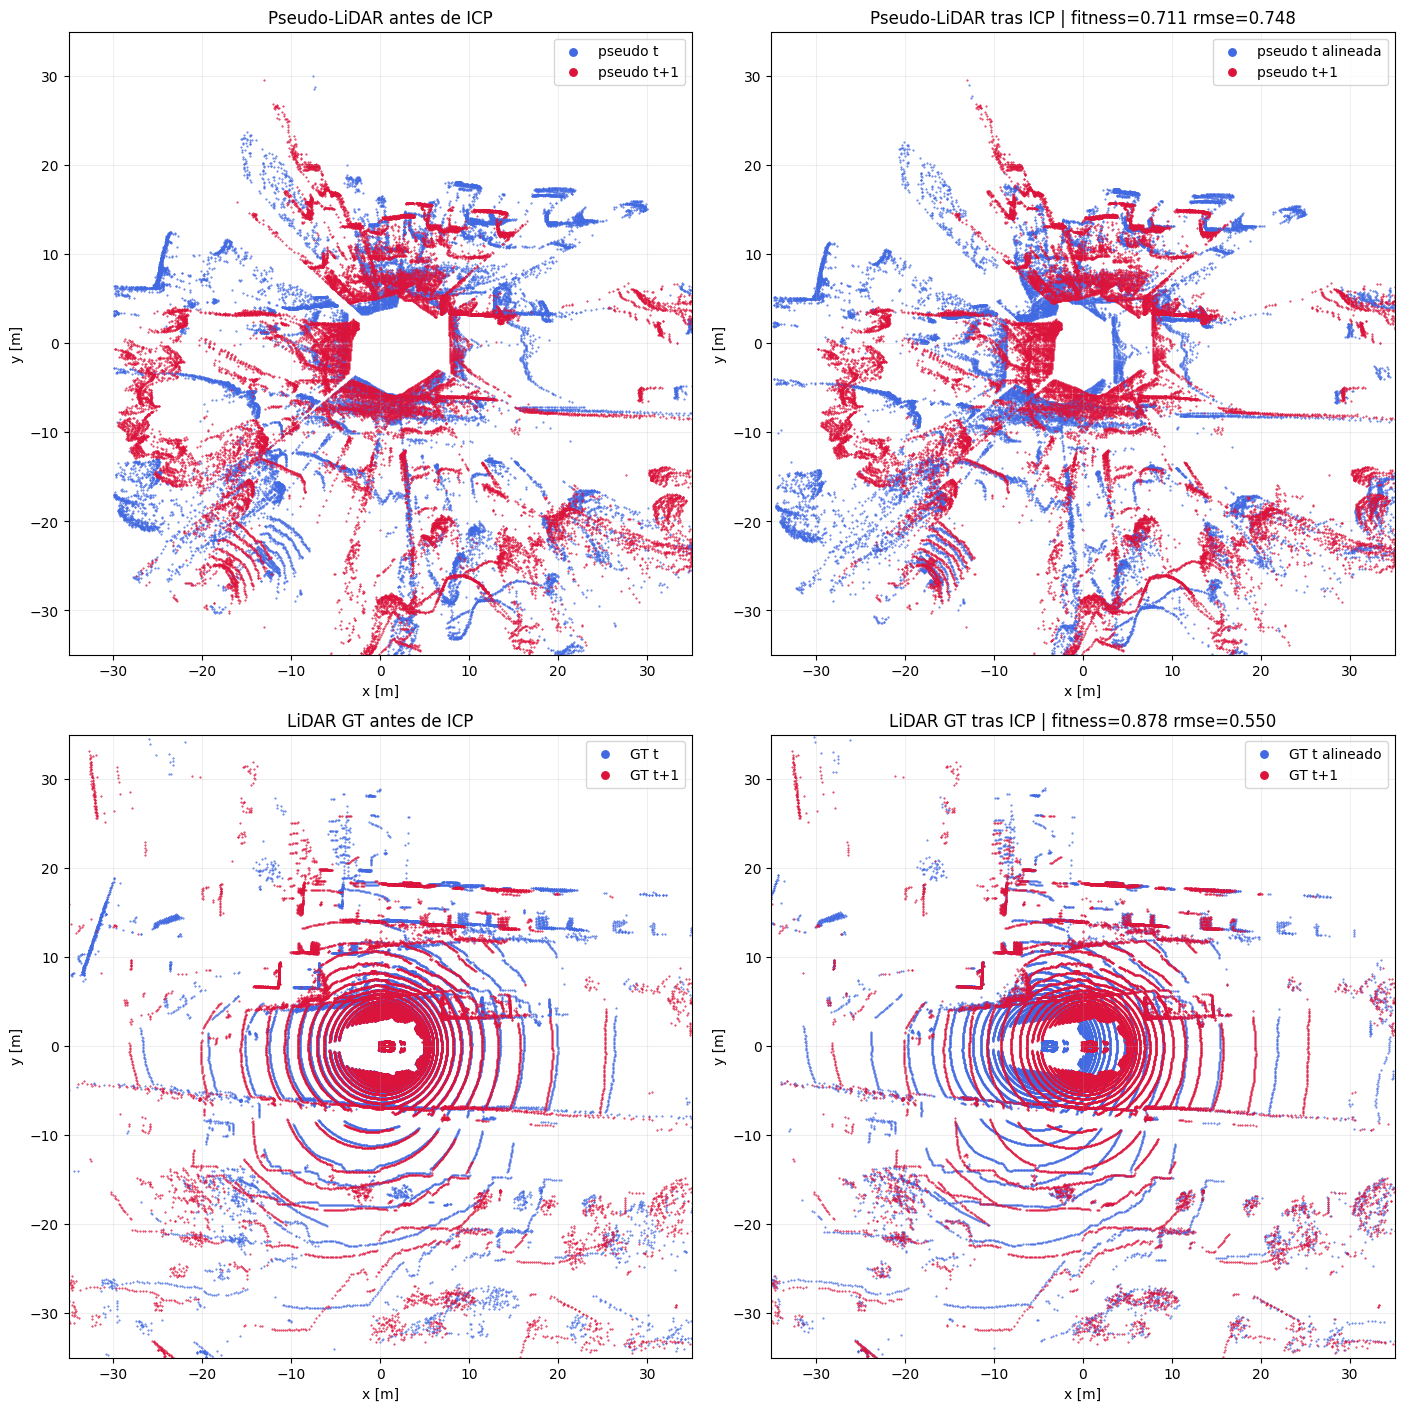

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14), constrained_layout=True)

axes[0, 0].scatter(src_pseudo_points[:, 0], src_pseudo_points[:, 1], s=0.2, c='royalblue', label='pseudo t')
axes[0, 0].scatter(tgt_pseudo_points[:, 0], tgt_pseudo_points[:, 1], s=0.2, c='crimson', label='pseudo t+1')
axes[0, 0].set_title('Pseudo-LiDAR antes de ICP')
axes[0, 0].legend(markerscale=12)

axes[0, 1].scatter(src_pseudo_aligned[:, 0], src_pseudo_aligned[:, 1], s=0.2, c='royalblue', label='pseudo t alineada')
axes[0, 1].scatter(tgt_pseudo_points[:, 0], tgt_pseudo_points[:, 1], s=0.2, c='crimson', label='pseudo t+1')
axes[0, 1].set_title(f"Pseudo-LiDAR tras ICP | fitness={pseudo_icp.fitness:.3f} rmse={pseudo_icp.inlier_rmse:.3f}")
axes[0, 1].legend(markerscale=12)

axes[1, 0].scatter(src_gt_points[:, 0], src_gt_points[:, 1], s=0.2, c='royalblue', label='GT t')
axes[1, 0].scatter(tgt_gt_points[:, 0], tgt_gt_points[:, 1], s=0.2, c='crimson', label='GT t+1')
axes[1, 0].set_title('LiDAR GT antes de ICP')
axes[1, 0].legend(markerscale=12)

axes[1, 1].scatter(src_gt_aligned[:, 0], src_gt_aligned[:, 1], s=0.2, c='royalblue', label='GT t alineado')
axes[1, 1].scatter(tgt_gt_points[:, 0], tgt_gt_points[:, 1], s=0.2, c='crimson', label='GT t+1')
axes[1, 1].set_title(f"LiDAR GT tras ICP | fitness={gt_icp.fitness:.3f} rmse={gt_icp.inlier_rmse:.3f}")
axes[1, 1].legend(markerscale=12)

for ax in axes.ravel():
    ax.set_xlim(*PLOT_XLIM)
    ax.set_ylim(*PLOT_YLIM)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')

plt.show()


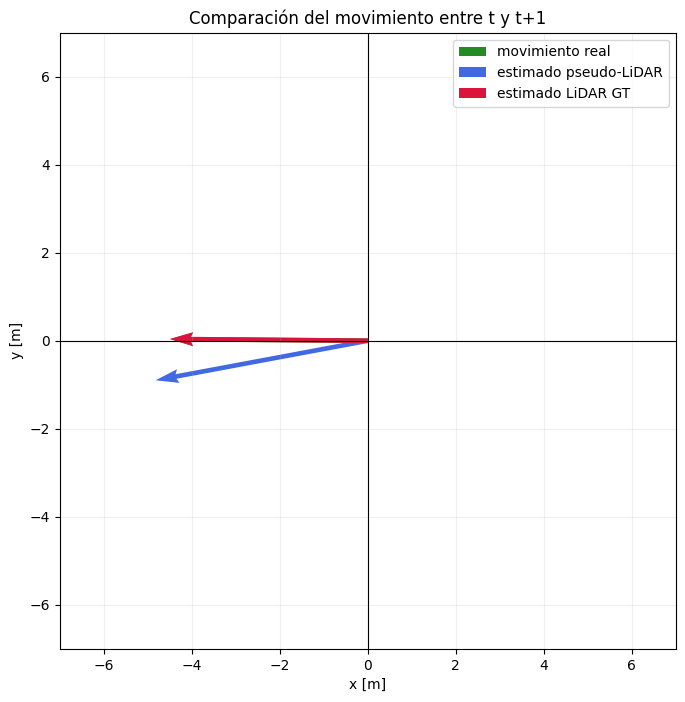

In [6]:
origin = np.array([0.0, 0.0])
gt_vec = gt_rel[:2, 3]
pseudo_vec = pseudo_icp.transformation[:2, 3]
gt_icp_vec = gt_icp.transformation[:2, 3]

plt.figure(figsize=(8, 8))
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.quiver(*origin, gt_vec[0], gt_vec[1], angles='xy', scale_units='xy', scale=1, color='forestgreen', label='movimiento real')
plt.quiver(*origin, pseudo_vec[0], pseudo_vec[1], angles='xy', scale_units='xy', scale=1, color='royalblue', label='estimado pseudo-LiDAR')
plt.quiver(*origin, gt_icp_vec[0], gt_icp_vec[1], angles='xy', scale_units='xy', scale=1, color='crimson', label='estimado LiDAR GT')
plt.xlim(-7, 7)
plt.ylim(-7, 7)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.2)
plt.legend()
plt.title('Comparación del movimiento entre t y t+1')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()


## Interpretación de las figuras

- Si el panel correspondiente a la pseudo-LiDAR tras ICP muestra un solapamiento razonable, puede considerarse que esa pareja de frames contiene geometría útil para el registro.
- Si el panel del LiDAR GT presenta un ajuste claramente mejor, esto ofrece una referencia directa del margen existente respecto al sensor real.
- En la figura de vectores, lo deseable es que la flecha asociada a la pseudo-LiDAR se aproxime lo máximo posible a la flecha del movimiento real.

Aunque este análisis no constituye un SLAM completo, sí permite valorar si la pseudo-LiDAR mantiene una consistencia temporal suficiente entre frames consecutivos.


## Visualizacion 3D interactiva

Las figuras anteriores son proyecciones 2D. Las siguientes visualizaciones HTML permiten rotar la escena y observar la alineacion de las nubes en 3D.

Enlaces directos:

- [Antes del registro](../outputs/scene-0061/pointcloud_phase_visualizations/phase_04a_front_pair_before_registration.html)
- [Despues de cfg_05](../outputs/scene-0061/pointcloud_phase_visualizations/phase_04b_front_pair_after_cfg05.html)


In [7]:
from IPython.display import IFrame, display, Markdown
VIS_DIR = ROOT / 'outputs' / 'scene-0061' / 'pointcloud_phase_visualizations'
display(Markdown('[Abrir indice de visualizaciones 3D](' + str(VIS_DIR / 'index.html') + ')'))
display(IFrame(src=str(VIS_DIR / 'phase_04a_front_pair_before_registration.html'), width='100%', height=720))
display(IFrame(src=str(VIS_DIR / 'phase_04b_front_pair_after_cfg05.html'), width='100%', height=720))


[Abrir indice de visualizaciones 3D](/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061/pointcloud_phase_visualizations/index.html)